In [1]:
pip install ultralytics opencv-python matplotlib

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 6.1 MB/s  0:00:00
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.8/40.2 MB 10.4 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/40.2 MB 11.2 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/40.2 MB 10.7 MB/s eta 0:00:04
   -------- ------------------------------- 8.9/40.2 MB 11.3 MB/s eta 0:00:03
   ----------- ---------------------------- 11.3/40.2 MB 11.3 MB/s eta 0:00:03
   ------------- -------------------------- 13.4/40.2 MB 11.1 MB/s eta 0:00:03
   ---------------- ----------------------- 16.5/40.2 MB 11.4 MB/s eta 0:00:03
   ------------------- -------------------- 19.4/40.2 MB 11.7 MB/s eta 0:00:02
   ---------------------- ----------------- 23.1/40.2 MB 12.3 MB/s eta 0:00:02
   -------------------------- ------------- 26.5/40.2 MB 12.6 MB/s eta 0:00:02
  


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # nano 모델

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\qhfkv\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
results = model(r"C:\Users\qhfkv\OneDrive\바탕 화면\공영주차장.png", conf=0.4)


image 1/1 C:\Users\qhfkv\OneDrive\ \.png: 288x640 30 cars, 133.1ms
Speed: 36.0ms preprocess, 133.1ms inference, 10.9ms postprocess per image at shape (1, 3, 288, 640)


(np.float64(-0.5), np.float64(1071.5), np.float64(439.5), np.float64(-0.5))

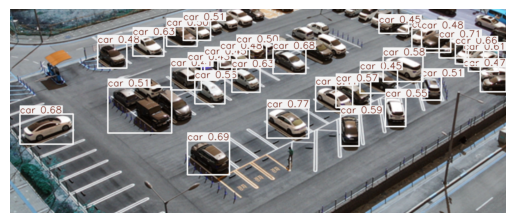

In [5]:
import matplotlib.pyplot as plt

img = results[0].plot()
plt.imshow(img)
plt.axis("off")

In [6]:
boxes = results[0].boxes

for box in boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(f"class:{cls}, conf:{conf:.2f}, bbox:({x1:.1f},{y1:.1f},{x2:.1f},{y2:.1f})")

class:2, conf:0.77, bbox:(555.4,213.3,645.3,278.6)
class:2, conf:0.71, bbox:(927.2,63.0,985.6,105.6)
class:2, conf:0.69, bbox:(383.9,284.4,474.3,357.1)
class:2, conf:0.68, bbox:(21.6,226.6,136.6,291.6)
class:2, conf:0.68, bbox:(568.4,87.5,639.9,139.9)
class:2, conf:0.66, bbox:(962.2,76.5,1023.8,118.1)
class:2, conf:0.63, bbox:(479.0,126.6,540.6,179.6)
class:2, conf:0.63, bbox:(265.5,57.8,332.7,101.8)
class:2, conf:0.61, bbox:(990.9,89.8,1055.5,134.8)
class:2, conf:0.59, bbox:(714.5,226.2,754.7,295.0)
class:2, conf:0.58, bbox:(806.8,101.2,892.0,156.1)
class:2, conf:0.57, bbox:(704.2,157.5,779.3,212.2)
class:2, conf:0.56, bbox:(399.9,150.5,464.4,204.7)
class:2, conf:0.55, bbox:(811.3,190.1,855.2,253.0)
class:2, conf:0.51, bbox:(374.7,25.5,433.5,67.2)
class:2, conf:0.51, bbox:(889.3,146.6,932.2,196.9)
class:2, conf:0.51, bbox:(211.9,168.5,349.4,267.4)
class:2, conf:0.50, bbox:(338.3,37.6,404.9,80.0)
class:2, conf:0.50, bbox:(489.0,73.2,554.4,121.2)
class:2, conf:0.48, bbox:(889.3,43.7,952

In [7]:
img_h, img_w = img.shape[:2]

cx = (x1 + x2) / 2 / img_w
cy = (y1 + y2) / 2 / img_h

print(f"normalized center: ({cx:.3f}, {cy:.3f})")

normalized center: (0.355, 0.340)
